# 02 · Pairwise IoU

**Question.** How much do the variant sets of two runs overlap, and which pipeline setting changes the calls most?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict.parquet` (built by notebook 01) and `data/reference/TestCases.csv`. It never reads `data/raw/`; no VCF is parsed.

**Produces** (`results/02_pairwise_iou/`):
- `tables/pairwise_iou.csv`: the IoU of every unordered pair of the 480 runs, self-pairs included (`run_1 <= run_2`). `iou` is unrounded; `iou_2dp` is rounded to 2 decimals, as in the legacy pair tables.
- `tables/grouped_iou.csv`: mean IoU over ordered pairs of runs from one sample that differ in exactly one setting: computing environment, mapper, variant caller, base recalibration, duplicate marking or trimming. One row per parameter and sample, with `mean_iou_2dp` (legacy) and `mean_iou`.
- `figures/iou_by_setting`: the grouped means as bars, one per sample. The values are also shown as a table under the figure.

**Rounding (D12).** The legacy pair tables and every mean built from them use the IoU rounded to 2 decimals. Both values are written; parity and the figure use the rounded one. Which to use for new analysis is undecided (`docs/legacy-deviations.md` D12).

**Does not.**
- draw the legacy per-sample heatmaps or clustermaps;
- cover the indel runs;
- compare against the truth set: that is `union_metrics.csv`, notebook 07.

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from swb import audit, config, io, metrics, viz

## Config

In [2]:
OUT = config.results_dir("02_pairwise_iou")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
LEVELS = config.FACTOR_LEVELS
FACTORS = [f for f in LEVELS if f != "Sample"]
CONTRASTS = config.IOU_CONTRASTS  # parameter name as in the legacy grouped table -> the one setting that differs
TOLERANCE = 1e-12  # both sides hold the same 2-decimal values; only the order of summation in the means can differ

## Load + validate

In [3]:
assert config.SETS_PARQUET.exists(), "run 01_variant_sets first"
sets = io.load_sets(config.SETS_PARQUET)
assert len(sets) == EXPECTED_RUNS and all(sets.values()), "the cache does not hold {} non-empty runs".format(EXPECTED_RUNS)
n_runs = len(sets)

# Run metadata: the 480 runs, factor levels, no missing values, one run per factor combination
meta = pd.read_csv(config.METADATA_CSV)
assert list(meta.columns) == config.METADATA_COLUMNS, list(meta.columns)
runs = io.study_runs(meta, sets, LEVELS, rename=config.METADATA_RENAME)
assert len(runs) == EXPECTED_RUNS, len(runs)
print(n_runs, "runs,", sum(len(s) for s in sets.values()), "variants")

480 runs, 692587 variants


## Analysis

In [4]:
pairs = metrics.pairwise_jaccard(sets)  # about half a minute
assert len(pairs) == n_runs * (n_runs + 1) // 2 and not pairs.duplicated(["run_1", "run_2"]).any()
assert (pairs["run_1"] <= pairs["run_2"]).all() and pairs[["iou", "iou_2dp"]].notna().all().all()
assert (pairs.loc[pairs["run_1"] == pairs["run_2"], "iou"] == 1).all(), "a run does not fully overlap itself"
assert (pairs["iou"] - pairs["iou_2dp"]).abs().max() <= 0.005 + 1e-12  # the most rounding to 2 decimals can change
pairs[["iou", "iou_2dp"]].describe()

,iou,iou_2dp
count,115440.000000,115440.000000
mean,0.419175,0.419200
std,0.189398,0.189412
min,0.010507,0.010000
25%,0.295064,0.300000
50%,0.403657,0.400000
75%,0.524035,0.520000
max,1.000000,1.000000


In [5]:
grouped = metrics.factor_contrast_means(pairs, runs, CONTRASTS, factors=FACTORS)
assert len(grouped) == len(CONTRASTS) * len(LEVELS["Sample"]), len(grouped)
assert grouped[["mean_iou_2dp", "mean_iou"]].notna().all().all()
grouped

,Sample,Parameter,n_pairs,mean_iou_2dp,mean_iou
0,EA,Computing Environment,96,1.000000,1.000000
1,FD,Computing Environment,96,1.000000,1.000000
2,IL,Computing Environment,96,1.000000,0.999986
3,LL,Computing Environment,96,1.000000,1.000000
4,NC,Computing Environment,96,1.000000,1.000000
5,EA,Mapper,96,0.601667,0.602271
6,FD,Mapper,96,0.505000,0.506350
7,IL,Mapper,96,0.628333,0.627783
8,LL,Mapper,96,0.589167,0.587720
9,NC,Mapper,96,0.655000,0.654943


## Save tables

Written to staging; moved to `results/02_pairwise_iou/` only if parity passes.

In [6]:
io.write_csv(pairs, STAGE.path(OUT / "tables" / "pairwise_iou.csv"), sort_by=["run_1", "run_2"])
io.write_csv(grouped, STAGE.path(OUT / "tables" / "grouped_iou.csv"), sort_by=["Parameter", "Sample"])

## Figures

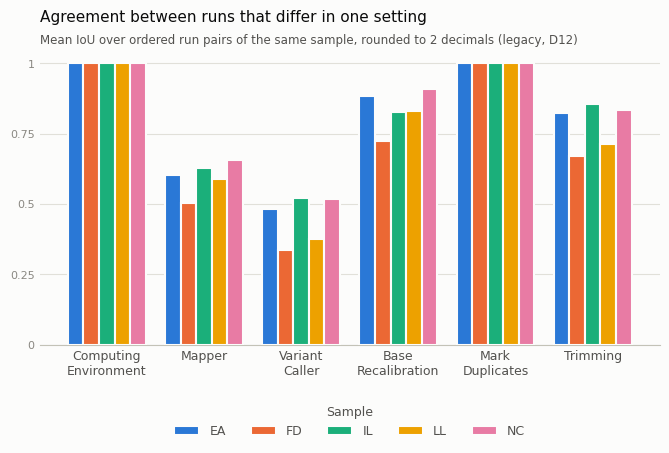

Sample,EA,FD,IL,LL,NC
Parameter,,,,,
Computing Environment,1.000,1.000,1.000,1.000,1.000
Mapper,0.602,0.505,0.628,0.589,0.655
Variant Caller,0.483,0.338,0.521,0.377,0.519
Base Recalibration,0.884,0.726,0.828,0.830,0.908
Mark Duplicates,1.000,1.000,1.000,1.000,1.000
Trimming,0.824,0.670,0.857,0.715,0.836


In [7]:
fig, ax = viz.iou_by_factor_bars(
    grouped, title="Agreement between runs that differ in one setting",
    subtitle="Mean IoU over ordered run pairs of the same sample, rounded to 2 decimals (legacy, D12)")
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "iou_by_setting"))
plt.show()
# Table view of the same values
grouped.pivot(index="Parameter", columns="Sample", values="mean_iou_2dp").reindex(list(CONTRASTS)).round(3)

## Parity check

Against the legacy pair tables, which hold the IoU rounded to 2 decimals for ordered pairs (self-pairs included), keyed by a text label built from the run's settings:
- `df_generateds_r_p.csv`: all ordered pairs of the 480 runs;
- `df_ea.csv`, `df_fd.csv`, `df_il.csv`, `df_ll.csv`, `df_nc.csv`: the pairs within each sample;
- `grouped_inter_union.csv`: the grouped means (30 rows).

Each must be reproduced to 1e-12. Results are moved out of staging only if every check passes.

In [8]:
labels = metrics.legacy_pair_labels(runs)
assert labels.is_unique
ordered = metrics.ordered_pairs(pairs)  # the legacy tables hold both directions
ordered["TestCase1"] = ordered["run_1"].map(labels)
ordered["TestCase2"] = ordered["run_2"].map(labels)

parity = audit.Parity()
legacy = pd.read_csv(config.LEGACY_PAIRS)
parity.check("legacy pair table has one row per ordered pair of the {} runs".format(n_runs),
             len(legacy) == n_runs ** 2 and not legacy.duplicated(["TestCase1", "TestCase2"]).any()
             and legacy["Inter/Union"].notna().all(), "{} rows".format(len(legacy)))
merged = ordered.merge(legacy, on=["TestCase1", "TestCase2"], how="outer", indicator=True)
diff = (merged["iou_2dp"] - merged["Inter/Union"]).abs()  # NaN wherever a pair is on one side only
parity.check("ordered pairs cover exactly the legacy pair table", (merged["_merge"] == "both").all(),
             {k: int(v) for k, v in merged["_merge"].value_counts().items()})
parity.check("iou_2dp == legacy df_generateds_r_p.csv Inter/Union (all {:,} ordered pairs)".format(len(legacy)),
             diff.max() <= TOLERANCE, "max |diff| {:.2e}".format(diff.max()))

for sample, path in config.LEGACY_PAIRS_BY_SAMPLE.items():
    leg = pd.read_csv(path)
    m = leg.merge(ordered, on=["TestCase1", "TestCase2"], how="left", indicator=True)
    d = (m["Inter/Union"] - m["iou_2dp"]).abs()
    parity.check("{}: iou_2dp == legacy {} ({:,} pairs)".format(sample, path.name, len(leg)),
                 len(leg) == int((runs["Sample"] == sample).sum()) ** 2 and (m["_merge"] == "both").all()
                 and d.max() <= TOLERANCE, "max |diff| {:.2e}".format(d.max()))

legacy_grouped = pd.read_csv(config.LEGACY_GROUPED_IOU)
mg = grouped.merge(legacy_grouped, left_on=["Sample", "Parameter"], right_on=["Sample1", "Parameter"],
                   how="outer", indicator=True)
dg = (mg["mean_iou_2dp"] - mg["Inter/Union"]).abs()
parity.check("mean_iou_2dp == legacy grouped_inter_union.csv Inter/Union ({} rows)".format(len(legacy_grouped)),
             (mg["_merge"] == "both").all() and dg.max() <= TOLERANCE, "max |diff| {:.2e}".format(dg.max()))

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (9 checks)
PASS  legacy pair table has one row per ordered pair of the 480 runs  [230400 rows]
PASS  ordered pairs cover exactly the legacy pair table  [{'both': 230400, 'left_only': 0, 'right_only': 0}]
PASS  iou_2dp == legacy df_generateds_r_p.csv Inter/Union (all 230,400 ordered pairs)  [max |diff| 0.00e+00]
PASS  EA: iou_2dp == legacy df_ea.csv (9,216 pairs)  [max |diff| 0.00e+00]
PASS  FD: iou_2dp == legacy df_fd.csv (9,216 pairs)  [max |diff| 0.00e+00]
PASS  IL: iou_2dp == legacy df_il.csv (9,216 pairs)  [max |diff| 0.00e+00]
PASS  LL: iou_2dp == legacy df_ll.csv (9,216 pairs)  [max |diff| 0.00e+00]
PASS  NC: iou_2dp == legacy df_nc.csv (9,216 pairs)  [max |diff| 0.00e+00]
PASS  mean_iou_2dp == legacy grouped_inter_union.csv Inter/Union (30 rows)  [max |diff| 7.77e-16]



## Audit summary

In [9]:
by_parameter = grouped.groupby("Parameter", sort=False).agg(
    n_pairs=("n_pairs", "max"), min_mean_iou_2dp=("mean_iou_2dp", "min"), max_mean_iou_2dp=("mean_iou_2dp", "max"))
lines = [
    "runs: {}; unordered pairs, self-pairs included: {:,}; ordered pairs compared with legacy: {:,}".format(
        n_runs, len(pairs), len(ordered)),
    "iou_2dp reproduces the legacy pair tables (all pairs and per sample) and grouped_inter_union.csv",
    "max |diff|: pairs {:.1e}, grouped means {:.1e}".format(diff.max(), dg.max()),
    "",
    "rounding to 2 decimals (D12, undecided): largest change of a pair {:.4f}, of a grouped mean {:.4f}".format(
        (pairs["iou"] - pairs["iou_2dp"]).abs().max(), (grouped["mean_iou"] - grouped["mean_iou_2dp"]).abs().max()),
    "",
    "grouped mean IoU (2 decimals) by parameter, range over the {} samples; n_pairs = ordered pairs per sample:".format(
        len(LEVELS["Sample"])),
    by_parameter.to_string(),
    "",
    "python {} | pandas {}".format(sys.version.split()[0], pd.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 480; unordered pairs, self-pairs included: 115,440; ordered pairs compared with legacy: 230,400
iou_2dp reproduces the legacy pair tables (all pairs and per sample) and grouped_inter_union.csv
max |diff|: pairs 0.0e+00, grouped means 7.8e-16

rounding to 2 decimals (D12, undecided): largest change of a pair 0.0050, of a grouped mean 0.0014

grouped mean IoU (2 decimals) by parameter, range over the 5 samples; n_pairs = ordered pairs per sample:
                       n_pairs  min_mean_iou_2dp  max_mean_iou_2dp
Parameter                                                         
Computing Environment       96          1.000000          1.000000
Mapper                      96          0.505000          0.655000
Variant Caller             192          0.338333          0.520833
Base Recalibration          96          0.725833          0.908333
Mark Duplicates             96          1.000000          1.000000
Trimming                    96          0.670000          0.857500

python 3